
**Dataset:** `train_features.parquet`  
**Target:** `departure_delayed` (1 = delayed ≥15 min, 0 = on-time)  


In [11]:
import sys
print(sys.executable)

d:\downloadsD\anaconda\python.exe


In [25]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE   = ['#2196F3', '#F44336']   # blue = on-time, red = delayed
BLUE      = '#2196F3'
RED       = '#F44336'
GRAY      = '#9E9E9E'
FIG_DIR   = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
train = pd.read_parquet(
    r"D:\Datascience\Project\flight-delay-predictor\data\processed\train_selected.parquet",
    engine="pyarrow"
)


train_pre = pd.read_parquet(
    r"D:\Datascience\Project\flight-delay-predictor\data\processed\train_preprocessed.parquet",
    engine="pyarrow"
)

print(f'Shape: {train.shape}')
print(f'Columns: {list(train.columns)}')
print(train_pre.columns)
train.head(3)




Shape: (2454517, 18)
Columns: ['tmpf', 'relh', 'mslp', 'num_cloud_layers', 'cloud_ceiling', 'day_of_week', 'tod_early_morning', 'tod_afternoon', 'tod_evening', 'is_holiday', 'is_holiday_window', 'prev_flight_delayed', 'weather_severity', 'route_congestion', 'airline_delay_rate', 'airport_delay_rate', 'route_delay_rate', 'departure_delayed']
Index(['tmpf', 'dwpf', 'relh', 'sknt', 'vsby', 'alti', 'mslp', 'feel', 'p01i',
       'is_gusty', 'gust', 'num_cloud_layers', 'cloud_ceiling',
       'skyc1_encoded', 'has_fog', 'has_thunder', 'has_rain', 'has_snow',
       'has_freezing', 'carrier_code', 'date_mmddyyyy', 'flight_number',
       'tail_number', 'destination_airport', 'scheduled_departure_time',
       'actual_departure_time', 'scheduled_elapsed_time_minutes',
       'actual_elapsed_time_minutes', 'departure_delay_minutes',
       'wheelsoff_time', 'taxiout_time_minutes', 'delay_carrier_minutes',
       'delay_weather_minutes', 'delay_national_aviation_system_minutes',
       'delay_s

,tmpf,relh,mslp,num_cloud_layers,cloud_ceiling,day_of_week,tod_early_morning,tod_afternoon,tod_evening,is_holiday,is_holiday_window,prev_flight_delayed,weather_severity,route_congestion,airline_delay_rate,airport_delay_rate,route_delay_rate,departure_delayed
0,43.0,82.04,1005.9,0,600.0,5,1,0,0,1,1,0,4.125,1,0.1821,0.171397,0.165106,1
1,-8.0,66.79,1022.9,0,15000.0,5,1,0,0,1,1,1,3.050,1,0.1821,0.165243,0.141800,0
2,59.0,51.18,1021.1,1,5000.0,6,0,0,0,0,1,0,1.050,2,0.1821,0.184881,0.237759,1


---
## 1. Univariate Analysis  Target Distribution
**Plot type:** Bar chart, donut (Categorical variable)  
**Variable:** `departure_delayed`


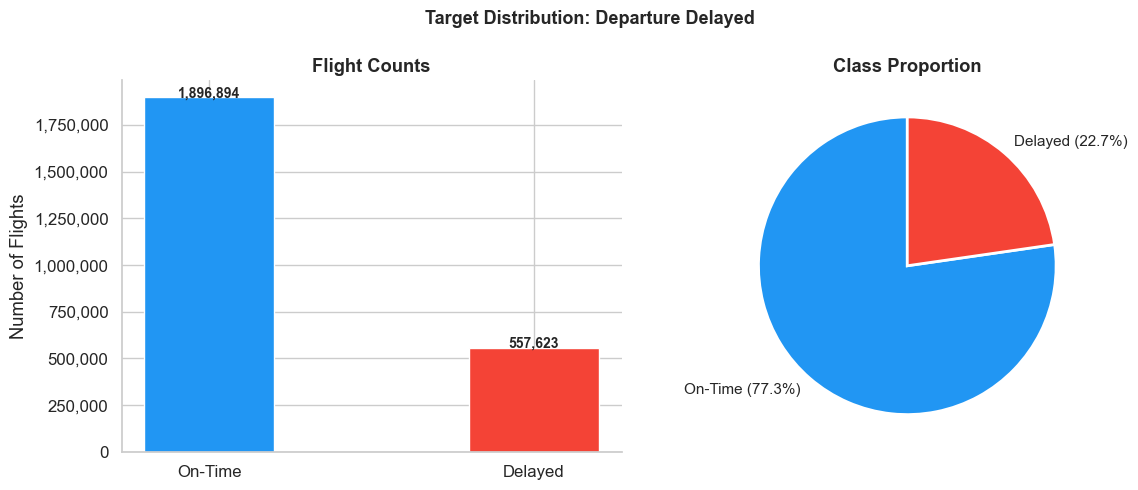

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Distribution: Departure Delayed', fontsize=13, fontweight='bold')

# Left: 
counts = train['departure_delayed'].value_counts().sort_index()
axes[0].bar(['On-Time', 'Delayed'], counts.values,
            color=[BLUE, RED], width=0.4, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Flight Counts', fontweight='bold')
axes[0].set_ylabel('Number of Flights')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=axes[0])

# Right:
labels = [f'On-Time ({counts[0]/counts.sum()*100:.1f}%)',
          f'Delayed ({counts[1]/counts.sum()*100:.1f}%)']
axes[1].pie(counts.values, labels=labels, colors=[BLUE, RED],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Plot 1
The dataset is **heavily imbalanced**: Approximately 77.3% (1,896,894) of flights are on-time (class 0), while only 22.7% (557,623) of flights are delayed (class 1) of 15 minutes or more. This 4:1 imbalance has direct consequences for modeling: raw accuracy is a misleading metric — a model predicting "always on-time" would score ~78% without learning anything;Therefore, evaluation metrics beyond accuracy (such as precision, recall, and F1-score) and techniques to handle class imbalance should be considered during model development.
This plot is the first and most important EDA finding because it shapes every downstream modeling choice.

---
## 2. Univariate Analysis  Continuous Feature Distributions (KDE + Histogram)
**Plot type:** KDE overlaid on histogram  
**Variables:** `weather_severity`, `tmpf`, `cloud_ceiling`

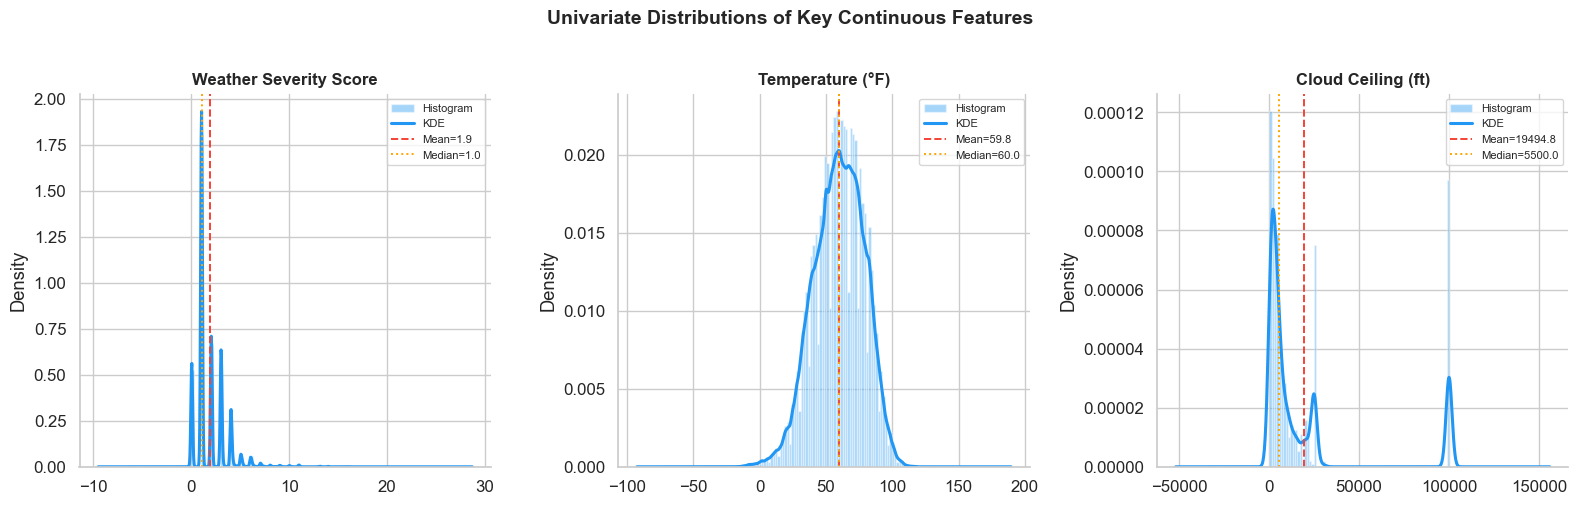

In [ ]:
features   = ['weather_severity', 'tmpf', 'cloud_ceiling']
feat_labels = ['Weather Severity Score', 'Temperature (°F)', 'Cloud Ceiling (ft)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Univariate Distributions of Key Continuous Features', fontsize=14, fontweight='bold', y=1.01)

for ax, feat, label in zip(axes, features, feat_labels):
    data = train[feat].dropna()

  
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    bin_width = 2 * iqr / (len(data) ** (1/3)) if iqr > 0 else 1
    n_bins = max(10, int((data.max() - data.min()) / bin_width))
    n_bins = min(n_bins, 80)   # cap to avoid noise

    ax.hist(data, bins=n_bins, color=BLUE, alpha=0.4, density=True, label='Histogram')
    data.plot.kde(ax=ax, color=BLUE, linewidth=2.2, label='KDE')

    # Mark mean and median
    ax.axvline(data.mean(),   color=RED,  linestyle='--', linewidth=1.4, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  linewidth=1.4, label=f'Median={data.median():.1f}')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Plot 2
**Weather Severity** shows a strong concentration near zero, indicating that most observations correspond to mild or no severe weather conditions. The distribution is right-skewed, suggesting rare but significant extreme events. The mean exceeds the median, confirming positive skew. **Temperature** follows an approximately normal distribution with mean and median closely aligned. This indicates stable behavior with no major skewness or outliers.
**Cloud** The mean (19,494 ft) is completely misleading here because of those three separate clusters. The median (5,500 ft) is more representative but still masks the multimodal structure. For your model, cloud ceiling probably shouldn't be used as a raw continuous feature — consider binning it into low/medium/unlimited categories instead, because those three clusters likely have very different delay rates. 

---
## 3. Bivariate Analysis — Weather Severity by Delay Class (Box)
**Plot type:** Box Plot + violin

**Variables:** `weather_severity` (continuous) × `departure_delayed` (categorical)

C:\Users\Jumana\AppData\Local\Temp\ipykernel_41280\3454927430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Jumana\AppData\Local\Temp\ipykernel_41280\3454927430.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


          mean  median    std
Status                       
Delayed  2.073    1.05  1.792
On-Time  1.891    1.05  1.650


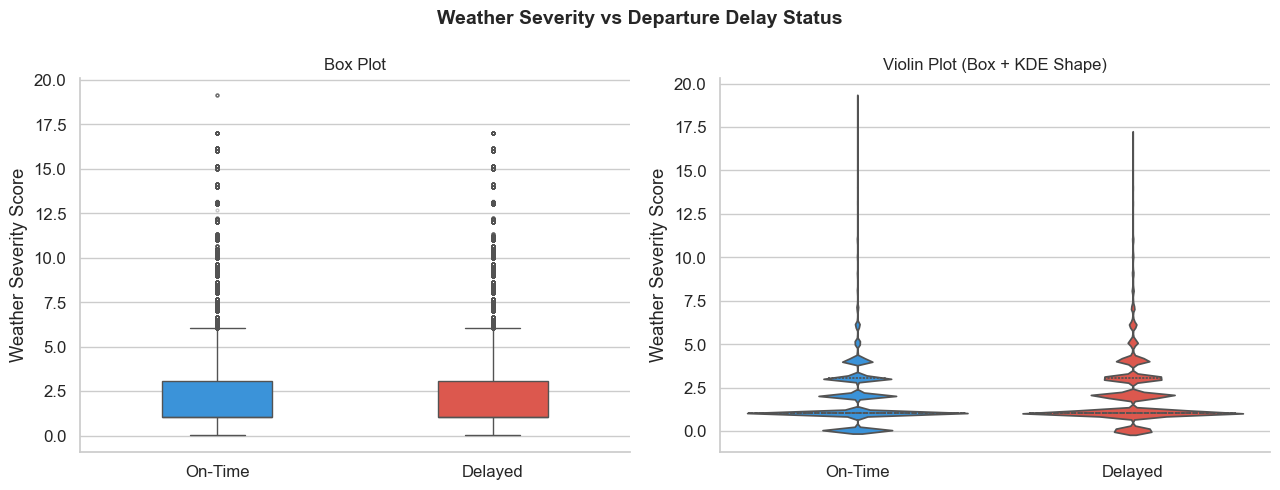

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Weather Severity vs Departure Delay Status', fontsize=14, fontweight='bold')

plot_df = train[['weather_severity', 'departure_delayed']].copy()
plot_df['Status'] = plot_df['departure_delayed'].map({0: 'On-Time', 1: 'Delayed'})

# ── Left:
sns.boxplot(
    data=plot_df, x='Status', y='weather_severity',
    palette={'On-Time': BLUE, 'Delayed': RED},
    order=['On-Time', 'Delayed'],
    width=0.4, flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title('Box Plot', fontsize=12)
axes[0].set_ylabel('Weather Severity Score')
axes[0].set_xlabel('')
sns.despine(ax=axes[0])

# ── Right: 
sns.violinplot(
    data=plot_df, x='Status', y='weather_severity',
    palette={'On-Time': BLUE, 'Delayed': RED},
    order=['On-Time', 'Delayed'],
    inner='quartile',   # show IQR lines inside violin
    ax=axes[1]
)
axes[1].set_title('Violin Plot (Box + KDE Shape)', fontsize=12)
axes[1].set_ylabel('Weather Severity Score')
axes[1].set_xlabel('')
sns.despine(ax=axes[1])

summary = plot_df.groupby('Status')['weather_severity'].agg(['mean','median','std'])
print(summary.round(3))

plt.tight_layout()
plt.savefig(FIG_DIR / '03_weather_severity_by_delay.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Bivariate Analysis — Weather Severity by Delay Class 


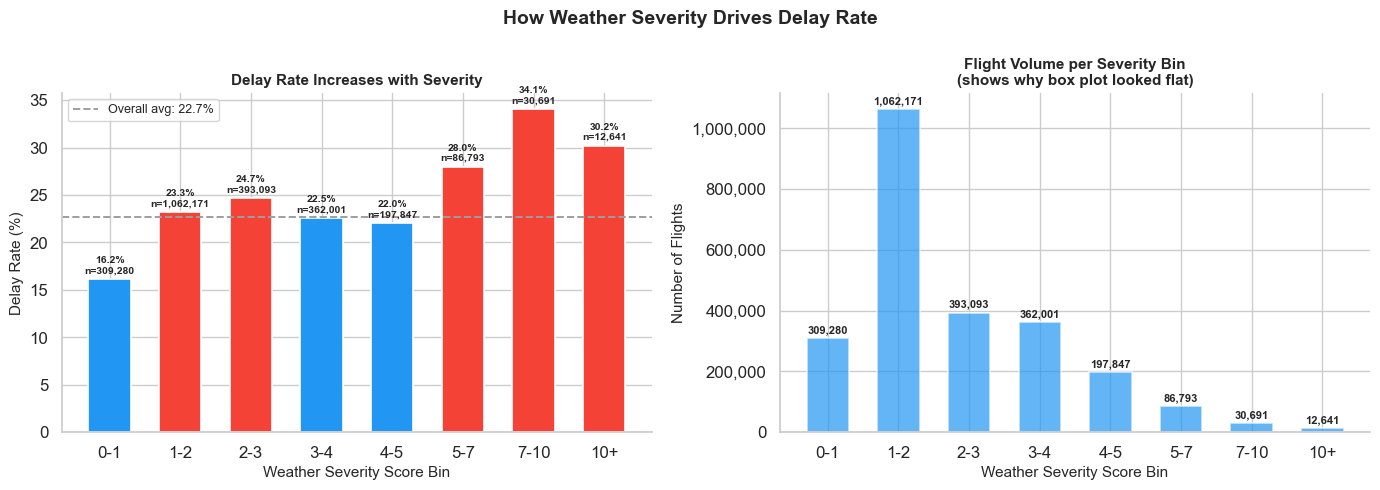

severity_bin  delay_rate   count
         0-1    0.161572  309280
         1-2    0.232511 1062171
         2-3    0.246738  393093
         3-4    0.225336  362001
         4-5    0.220074  197847
         5-7     0.28008   86793
        7-10    0.340588   30691
         10+    0.302191   12641


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('How Weather Severity Drives Delay Rate',
             fontsize=14, fontweight='bold')

plot_df = train[['weather_severity', 'departure_delayed']].copy()

# ── Left: Delay rate per severity bin
# Bin severity into intervals
plot_df['severity_bin'] = pd.cut(
    plot_df['weather_severity'],
    bins=[0, 1, 2, 3, 4, 5, 7, 10, 25],
    labels=['0-1', '1-2', '2-3', '3-4', '4-5', '5-7', '7-10', '10+']
)

bin_stats = (
    plot_df.groupby('severity_bin', observed=True)
    .agg(
        delay_rate=('departure_delayed', 'mean'),
        count=('departure_delayed', 'count')
    )
    .reset_index()
)

bar_colors = [RED if r > train['departure_delayed'].mean()
              else BLUE for r in bin_stats['delay_rate']]

bars = axes[0].bar(
    bin_stats['severity_bin'].astype(str),
    bin_stats['delay_rate'] * 100,
    color=bar_colors, width=0.6,
    edgecolor='white', linewidth=1.2
)

for bar, rate, count in zip(bars, bin_stats['delay_rate'],
                             bin_stats['count']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{rate*100:.1f}%\nn={count:,}',
        ha='center', va='bottom', fontsize=7.5, fontweight='bold'
    )

axes[0].axhline(train['departure_delayed'].mean() * 100,
                color=GRAY, linestyle='--', linewidth=1.4,
                label=f'Overall avg: '
                      f'{train["departure_delayed"].mean()*100:.1f}%')

axes[0].set_title('Delay Rate Increases with Severity',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Delay Rate (%)', fontsize=11)
axes[0].set_xlabel('Weather Severity Score Bin', fontsize=11)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# ── Right: Flight volume per bin 
axes[1].bar(
    bin_stats['severity_bin'].astype(str),
    bin_stats['count'],
    color=BLUE, alpha=0.7, width=0.6,
    edgecolor='white', linewidth=1.2
)

for i, (count, rate) in enumerate(zip(bin_stats['count'],
                                       bin_stats['delay_rate'])):
    axes[1].text(i, count + bin_stats['count'].max() * 0.01,
                 f'{count:,}', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

axes[1].set_title('Flight Volume per Severity Bin\n'
                  '(shows why box plot looked flat)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Flights', fontsize=11)
axes[1].set_xlabel('Weather Severity Score Bin', fontsize=11)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR / '03_weather_severity_delay_rate.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(bin_stats[['severity_bin', 'delay_rate', 'count']].to_string(index=False))

### Interpretation — Plot 4
Both groups show a similar distribution, with most values concentrated at low severity levels (around 0–3), indicating that the majority of flights occur under mild weather conditions. The median weather severity for delayed flights is slightly higher than for on-time flights, suggesting a weak tendency for delays to occur under worse weather.

However, there is substantial overlap between the two distributions, meaning weather severity alone does not clearly distinguish delayed flights from on-time ones. Both categories also contain several high-value outliers, representing rare extreme weather events, which occur in both delayed and on-time flights.

Overall, this suggests that while higher weather severity may slightly increase the likelihood of delays, it is not a strong standalone factor, and other variables likely play a more significant role in determining delays.

---
## 5. Bivariate Analysis — Weather Severity by Delay Class > 12


C:\Users\Jumana\AppData\Local\Temp\ipykernel_41280\952657507.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


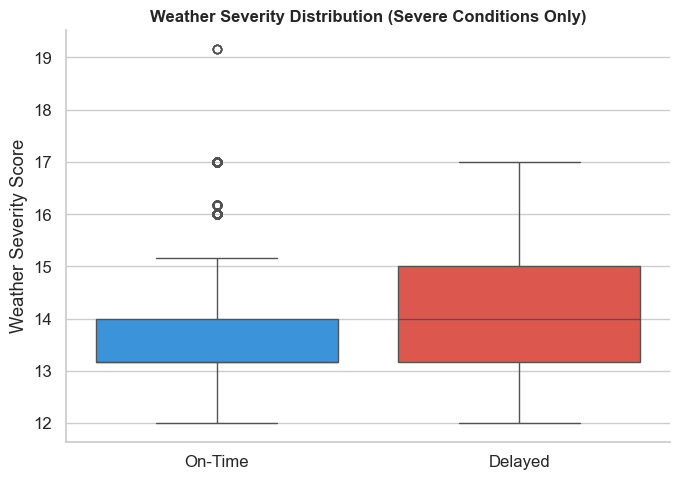

In [ ]:



severe_df = train[train['weather_severity'] >= 12].copy()

severe_df['Status'] = severe_df['departure_delayed'].map({
    0: 'On-Time',
    1: 'Delayed'
})

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=severe_df,
    x='Status',
    y='weather_severity',
    palette={'On-Time': BLUE, 'Delayed': RED}
)

plt.title('Weather Severity Distribution (Severe Conditions Only)',
          fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylabel('Weather Severity Score')

sns.despine()
plt.tight_layout()
plt.show()

# Insights
Under severe weather conditions, delayed flights tend to occur at slightly higher severity levels compared to on-time flights. However, the substantial overlap between the two distributions indicates that weather severity alone is not a strong standalone predictor of delays, but rather a contributing factor alongside other variables.

---
## 6. Bivariate Analysis — Delay Rate by Time of Day
**Plot type:** Bar chart (Categorical vs Continuous — mean of target)  
**Variables:** `tod_*` one-hot columns, reconstructed = `time_of_day` × `departure_delayed`

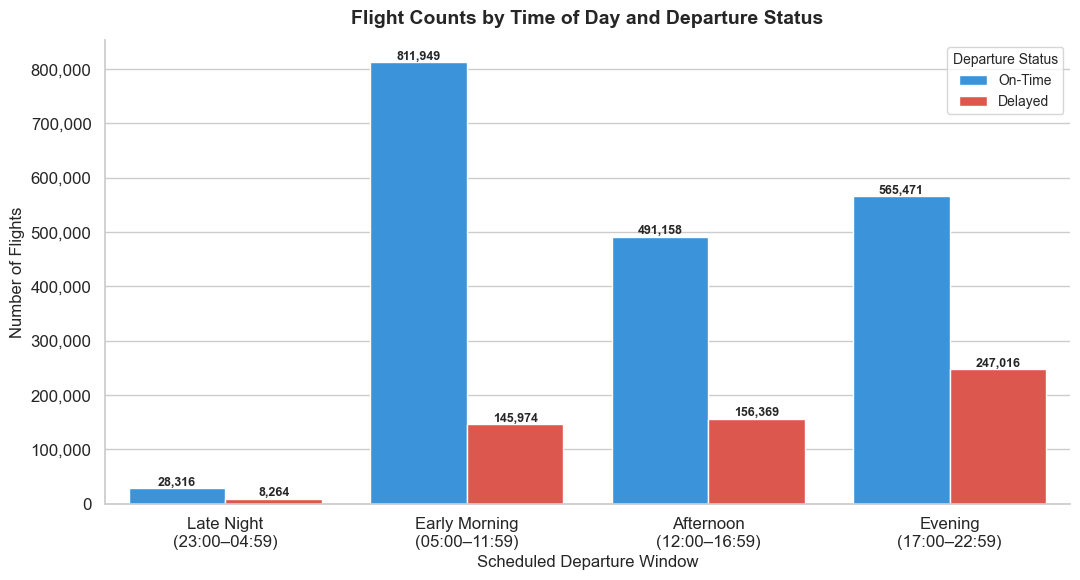

In [34]:
# Reconstruct time_of_day from one-hot columns
tod_cols = ['tod_late_night', 'tod_early_morning', 'tod_afternoon', 'tod_evening']
tod_labels = {
    'tod_late_night':    'Late Night\n(23:00–04:59)',
    'tod_early_morning': 'Early Morning\n(05:00–11:59)',
    'tod_afternoon':     'Afternoon\n(12:00–16:59)',
    'tod_evening':       'Evening\n(17:00–22:59)',
}

available_tod = [c for c in tod_cols if c in train.columns]

# Flights where no tod column is 1 get 'late_night' (it was dropped as reference)
def get_tod(row):
    for c in available_tod:
        if row[c] == 1:
            return c
    return 'tod_late_night'

plot_df = train[available_tod + ['departure_delayed']].copy()
plot_df['time_of_day'] = plot_df.apply(get_tod, axis=1)

tod_stats = plot_df.groupby('time_of_day').agg(
    delay_rate=('departure_delayed', 'mean'),
    count=('departure_delayed', 'count')
).reindex([c for c in tod_cols if c in plot_df['time_of_day'].unique()])



fig, ax = plt.subplots(figsize=(11, 6))

# ── Build counts ──────────────────────────────────────────────────────────────
plot_df = train[available_tod + ['departure_delayed']].copy()
plot_df['time_of_day'] = plot_df.apply(get_tod, axis=1)
plot_df['Status']      = plot_df['departure_delayed'].map({0: 'On-Time', 1: 'Delayed'})
plot_df['TOD_Label']   = plot_df['time_of_day'].map(tod_labels)

tod_order = [
    'Late Night\n(23:00–04:59)',
    'Early Morning\n(05:00–11:59)',
    'Afternoon\n(12:00–16:59)',
    'Evening\n(17:00–22:59)',
]

counts_df = (
    plot_df.groupby(['TOD_Label', 'Status'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=counts_df,
    x='TOD_Label', y='count',
    hue='Status',
    hue_order=['On-Time', 'Delayed'],
    palette={'On-Time': BLUE, 'Delayed': RED},
    order=tod_order,
    ax=ax
)

# ── Annotate each bar with its count ─────────────────────────────────────────
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 500,          # small offset above bar
            f'{int(height):,}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_title('Flight Counts by Time of Day and Departure Status',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_xlabel('Scheduled Departure Window', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Departure Status', fontsize=10, title_fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(FIG_DIR / '04_clustered_bar_time_of_day.png', dpi=150, bbox_inches='tight')
plt.show()





### Interpretation — Plot 6
The clustered bar chart reveals two simultaneous patterns. First, volume: early morning dominates total flight count (nearly 1 million flights) while late night is the quietest window — this alone explains why the raw delayed bar is tallest in early morning despite having the lowest delay rate. This is exactly the limitation of raw counts: a tall red bar does not mean a high-risk window. Second, delay rate: when you calculate delayed ÷ total per bin, evening (17:00–22:59) has the highest delay rate at ~30%, nearly double the early morning rate of ~15%. Afternoon sits in the middle at ~24%, and late night at ~22.6%

---
## 7. Pattern Discovery — Delay Rate by Day of Week (Seasonality)
**Plot type:** Bar chart with trend line — Seasonality detection  
**Variables:** `day_of_week` × `departure_delayed`

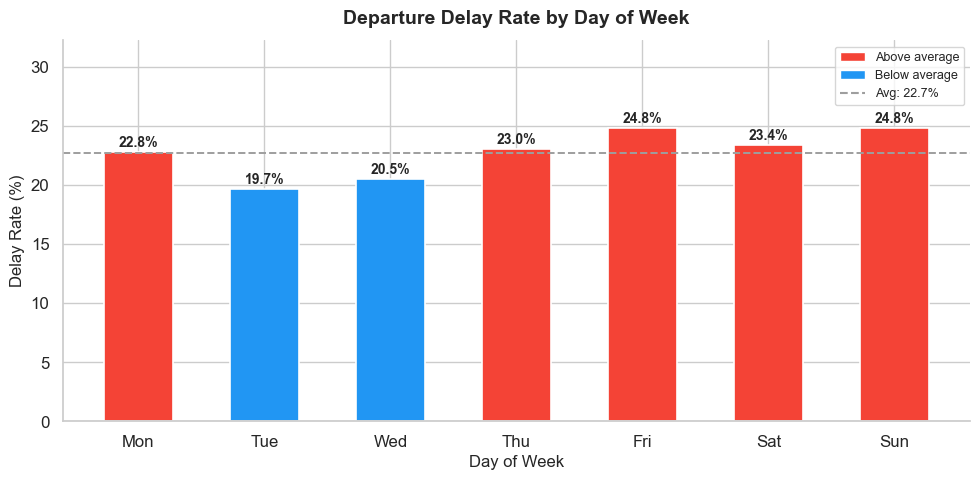

day_name  delay_rate  count
     Mon    0.227506 358778
     Tue    0.196882 344547
     Wed    0.205108 348679
     Thu    0.230023 359208
     Fri    0.247755 361579
     Sat    0.233866 326148
     Sun    0.247943 355578


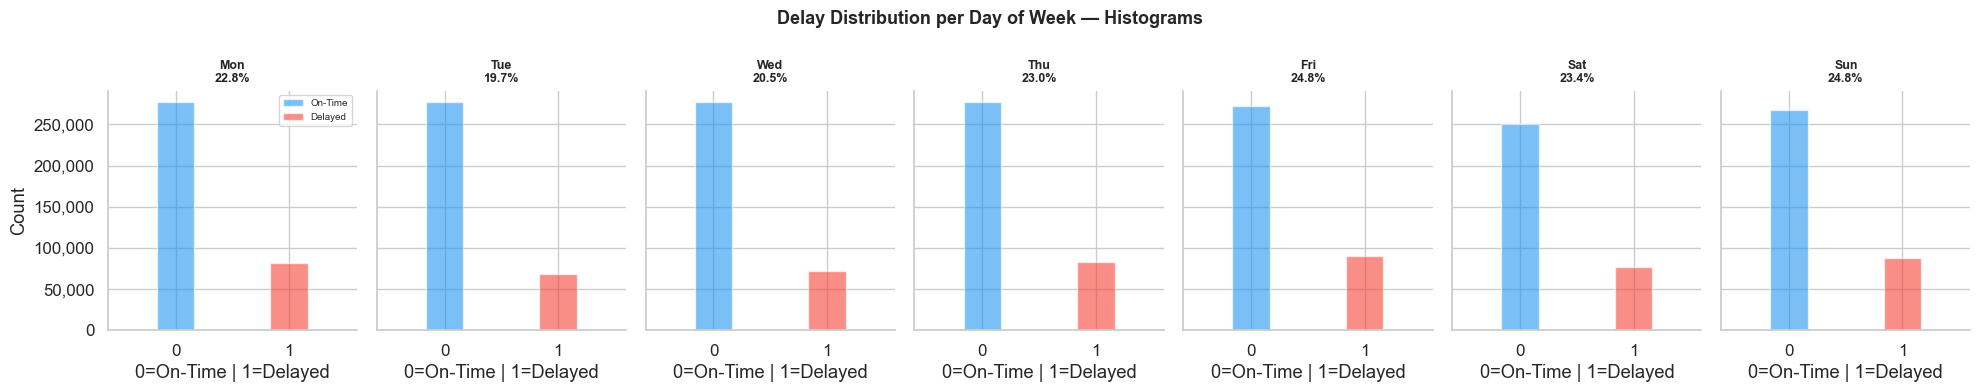

In [ ]:
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

dow_stats = train.groupby('day_of_week').agg(
    delay_rate=('departure_delayed', 'mean'),
    count=('departure_delayed', 'count')
).reset_index()
dow_stats['day_name'] = dow_stats['day_of_week'].map(day_map)

fig, ax = plt.subplots(figsize=(10, 5))

overall_rate = train['departure_delayed'].mean() * 100

bar_colors = [RED if r > overall_rate / 100 else BLUE for r in dow_stats['delay_rate']]
bars = ax.bar(dow_stats['day_name'], dow_stats['delay_rate'] * 100,
              color=bar_colors, width=0.55, edgecolor='white', linewidth=1.2)


for bar, rate in zip(bars, dow_stats['delay_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{rate*100:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )


ax.axhline(overall_rate, color=GRAY, linestyle='--', linewidth=1.4,
           label=f'Overall avg: {overall_rate:.1f}%')

ax.set_title('Departure Delay Rate by Day of Week', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Delay Rate (%)', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylim(0, dow_stats['delay_rate'].max() * 130)
ax.legend(fontsize=10)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED, label='Above average'),
    Patch(facecolor=BLUE, label='Below average'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color=GRAY, linestyle='--', label=f'Avg: {overall_rate:.1f}%')],
          fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_delay_rate_by_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

print(dow_stats[['day_name', 'delay_rate', 'count']].to_string(index=False))


fig2, axes2 = plt.subplots(1, 7, figsize=(20, 4), sharey=True)
fig2.suptitle('Delay Distribution per Day of Week — Histograms',
              fontsize=13, fontweight='bold')

for j, (_, row) in enumerate(dow_stats.iterrows()):
    subset = train[train['day_of_week'] == row['day_of_week']]

    for val, color, label in [(0, BLUE, 'On-Time'), (1, RED, 'Delayed')]:
        axes2[j].hist(
            subset[subset['departure_delayed'] == val]['departure_delayed'],
            bins=3,
            color=color,
            alpha=0.6,
            label=label,
            edgecolor='white'
        )

    axes2[j].set_title(
        f"{row['day_name']}\n{row['delay_rate']*100:.1f}%",
        fontsize=9,
        fontweight='bold'
    )

    axes2[j].set_xlabel('0=On-Time | 1=Delayed')
    axes2[j].set_ylabel('Count' if j == 0 else '')

    axes2[j].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    if j == 0:
        axes2[j].legend(fontsize=7)

    sns.despine(ax=axes2[j])

plt.tight_layout()
plt.savefig(FIG_DIR / '05b_dow_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Plot 7
Delay rates show a **clear weekly pattern (seasonality)**: Midweek days especially Tuesday and Wednesday have the lowest delay rates, both sitting noticeably below the overall average of about 22.7%, which suggests these are the most reliable days to travel. In contrast, delays begin to increase from Thursday onward, peaking on Friday and Sunday at around 24.8%, making them the worst days in terms of punctuality. This upward trend toward the weekend likely reflects higher travel demand, increased congestion, and tighter scheduling pressures. Saturday also remains above average, reinforcing the idea that weekends are generally more delay-prone. Overall, the visualization highlights a consistent pattern: flight operations are smoother during the middle of the week and become progressively less reliable as the weekend approaches.

---
## 8. Bivariate Analysis 
**Plot type:**  stacked bar chart and two-way contingenct table (Two Categorical Variables)  
**Variables:** `prev_flight_delayed` × `departure_delayed`

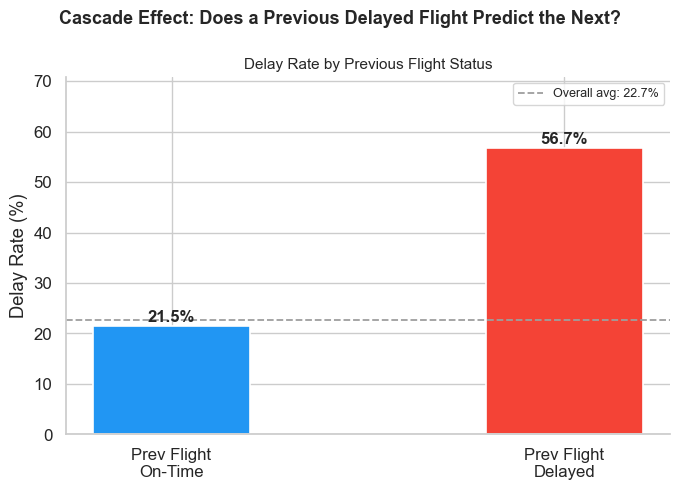

In [49]:
# Delay rate by previous flight status
delay_by_prev = train.groupby('prev_flight_delayed')['departure_delayed'].mean() * 100
delay_by_prev.index = ['Prev Flight\nOn-Time', 'Prev Flight\nDelayed']

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Cascade Effect: Does a Previous Delayed Flight Predict the Next?',
             fontsize=13, fontweight='bold')

bars = ax.bar(delay_by_prev.index, delay_by_prev.values,
              color=[BLUE, RED], width=0.4, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, delay_by_prev.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.axhline(overall_rate, color=GRAY, linestyle='--', linewidth=1.3,
           label=f'Overall avg: {overall_rate:.1f}%')

ax.set_title('Delay Rate by Previous Flight Status', fontsize=11)
ax.set_ylabel('Delay Rate (%)')
ax.set_ylim(0, delay_by_prev.max() * 1.25)
ax.legend(fontsize=9)

sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_delay_by_previous_flight.png', dpi=150, bbox_inches='tight')  
plt.show()

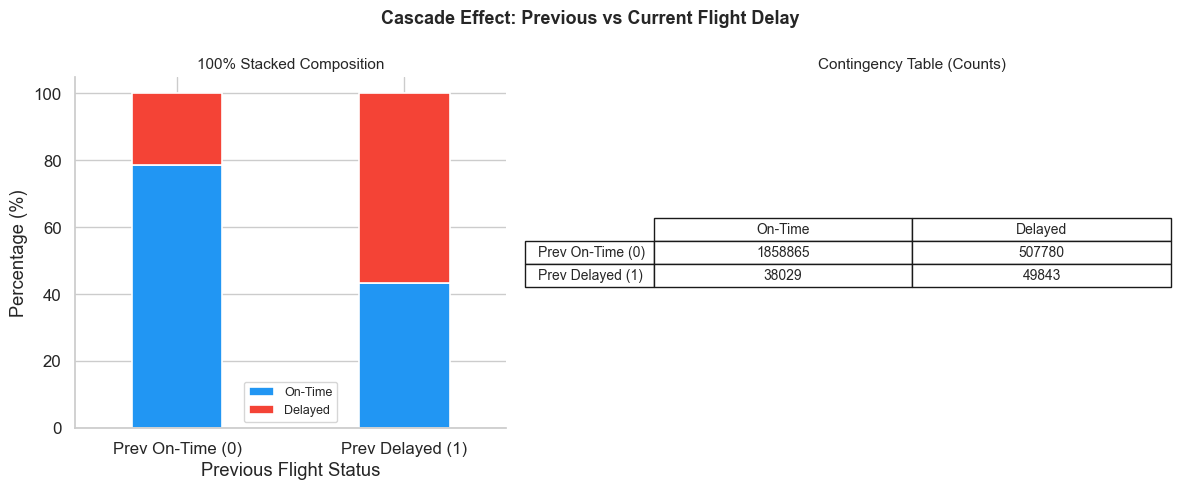

In [ ]:
# Raw counts table
counts_table = pd.crosstab(
    train['prev_flight_delayed'],
    train['departure_delayed']
)

counts_table.index   = ['Prev On-Time (0)', 'Prev Delayed (1)']
counts_table.columns = ['On-Time', 'Delayed']


crosstab = pd.crosstab(
    train['prev_flight_delayed'],
    train['departure_delayed'],
    normalize='index'
) * 100

crosstab.index   = ['Prev On-Time (0)', 'Prev Delayed (1)']
crosstab.columns = ['On-Time', 'Delayed']


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cascade Effect: Previous vs Current Flight Delay', 
             fontsize=13, fontweight='bold')

# Left: stacked %
crosstab.plot(kind='bar', stacked=True, ax=axes[0],
              color=[BLUE, RED], edgecolor='white', linewidth=1.2, width=0.4)

axes[0].set_title('100% Stacked Composition', fontsize=11)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Previous Flight Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['On-Time', 'Delayed'], fontsize=9)

sns.despine(ax=axes[0])

# Right: table
axes[1].axis('off')

table = axes[1].table(
    cellText=counts_table.values,
    rowLabels=counts_table.index,
    colLabels=counts_table.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

axes[1].set_title('Contingency Table (Counts)', fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / '06c_stacked_with_table.png', dpi=150, bbox_inches='tight')
plt.show()


### Insight: Cascade Effect of Flight Delays

Both the stacked bar chart and the contingency table consistently reveal a strong **delay propagation (cascade) effect**. Flights following an **on-time previous flight** have a relatively low delay rate (~21.5%), whereas flights following a **delayed previous flight** experience a sharply higher delay rate (~56.7%). This means the likelihood of delay more than **doubles** when the preceding flight is delayed. The stacked bar chart highlights this shift visually through a clear increase in the proportion of delayed flights, while the contingency table confirms the result with actual counts, showing that delayed flights even become the **majority** in the “previous delayed” group. Despite the smaller number of such cases, the effect is substantial and reliable, indicating that delays tend to propagate across flights. This makes `prev_flight_delayed` a **highly influential predictive feature** for modeling flight delays.


---
## 9. Multivariate Analysis — Correlation Heatmap
**Plot type:** Correlation matrix heatmap  
**Variables:** All numeric features + target

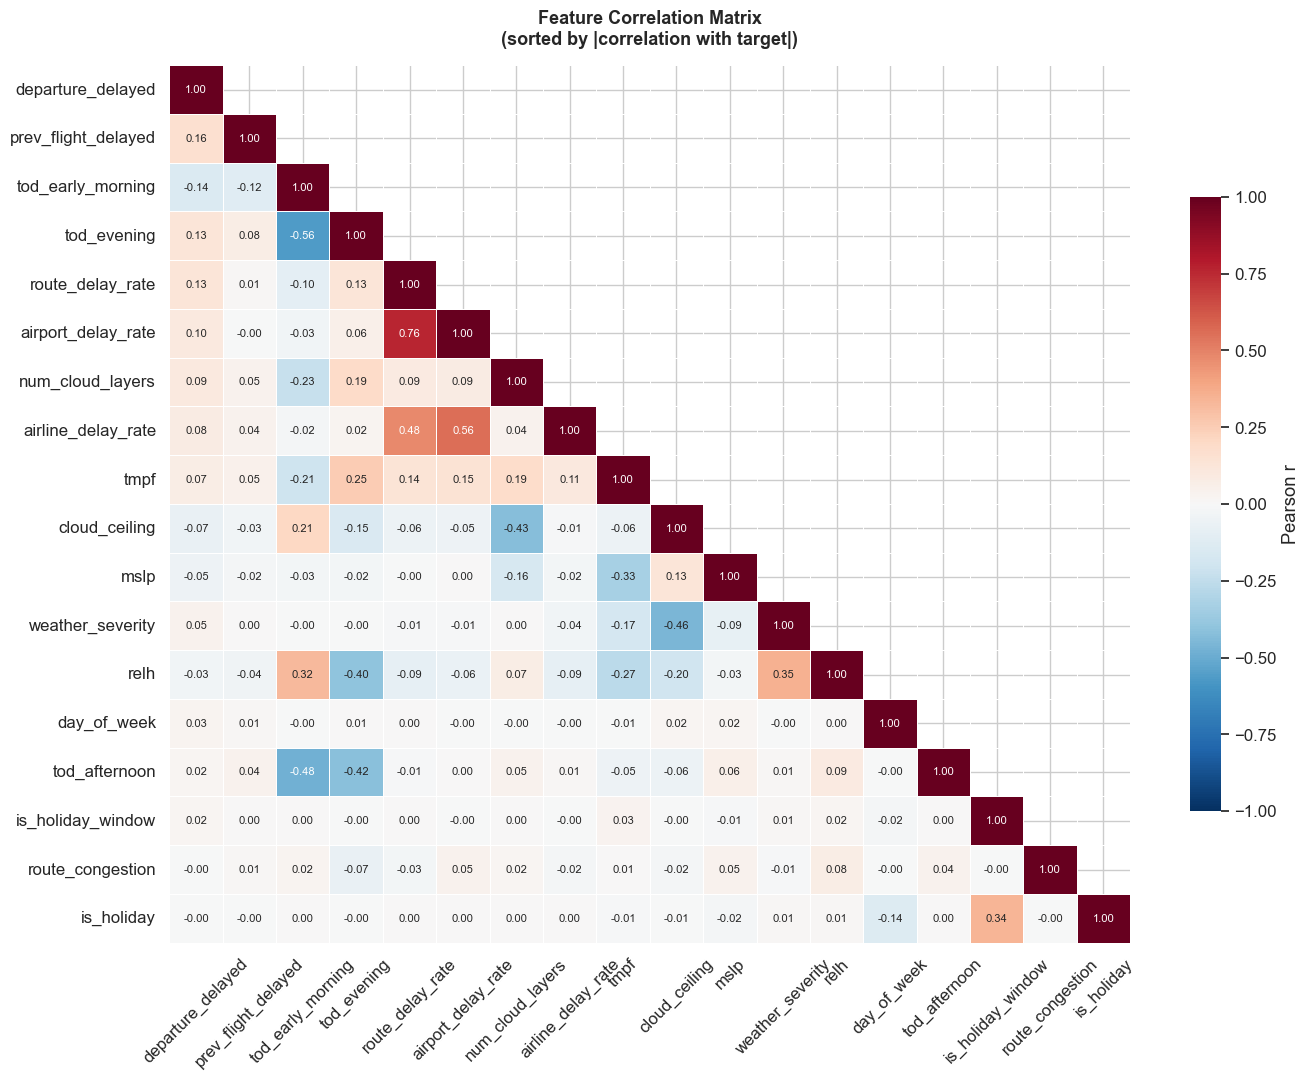

Top correlations with departure_delayed:
prev_flight_delayed    0.1564
tod_early_morning      0.1428
tod_evening            0.1290
route_delay_rate       0.1254
airport_delay_rate     0.0957
num_cloud_layers       0.0944
airline_delay_rate     0.0818
tmpf                   0.0721
cloud_ceiling          0.0710
mslp                   0.0500
weather_severity       0.0453
relh                   0.0314
day_of_week            0.0302
tod_afternoon          0.0204
is_holiday_window      0.0159
route_congestion       0.0039
is_holiday             0.0019
Name: departure_delayed, dtype: float64


In [ ]:
# Select numeric columns only
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix
corr = train[numeric_cols].corr()


target_corr_order = corr['departure_delayed'].abs().sort_values(ascending=False).index
corr_sorted = corr.loc[target_corr_order, target_corr_order]

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)   # show lower triangle + diagonal

sns.heatmap(
    corr_sorted,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix\n(sorted by |correlation with target|)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / '07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with target
print('Top correlations with departure_delayed:')
print(corr['departure_delayed'].drop('departure_delayed').abs().sort_values(ascending=False).round(4))

### Insight: Feature Correlation with Flight Delays
The correlation analysis shows that no single feature has a strong linear relationship with flight delays, as all correlations with departure_delayed are relatively low (maximum ≈ 0.16). This suggests that flight delays are influenced by a combination of factors rather than one dominant variable, indicating a complex, multi-factor problem.

---
## 10. Univariate Analysis 
**Plot type:** bar chart  
**Variables:** airline_delay_rate

C:\Users\Jumana\AppData\Local\Temp\ipykernel_41280\1427475553.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(airline_rates['carrier_name'], rotation=45, ha='right')


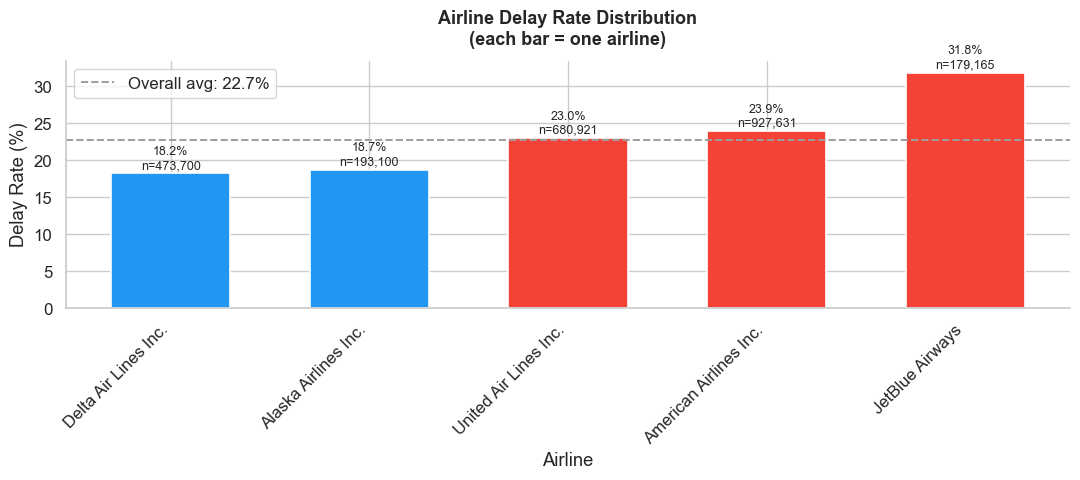

In [ ]:


fig, ax = plt.subplots(figsize=(11, 5))

# Use train_pre (IMPORTANT)
airline_rates = (
    train_pre.groupby('carrier_name')['departure_delayed']
    .agg(
        delay_rate='mean',
        count='size'
    )
    .reset_index()
    .sort_values('delay_rate')
)

# Overall average (also from train_pre)
overall_avg = train_pre['departure_delayed'].mean()

# Colors
bar_colors = [
    RED if r > overall_avg else BLUE
    for r in airline_rates['delay_rate']
]

# Plot
bars = ax.bar(
    airline_rates['carrier_name'],
    airline_rates['delay_rate'] * 100,
    color=bar_colors,
    width=0.6,
    edgecolor='white',
    linewidth=1.2
)

# Labels on bars
for bar, rate, count in zip(bars, airline_rates['delay_rate'], airline_rates['count']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{rate*100:.1f}%\nn={count:,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Average line
ax.axhline(
    overall_avg * 100,
    color=GRAY,
    linestyle='--',
    linewidth=1.4,
    label=f'Overall avg: {overall_avg*100:.1f}%'
)

# Titles
ax.set_title(
    'Airline Delay Rate Distribution\n(each bar = one airline)',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_ylabel('Delay Rate (%)')
ax.set_xlabel('Airline')

ax.set_xticklabels(airline_rates['carrier_name'], rotation=45, ha='right')

ax.legend()
sns.despine()
plt.tight_layout()

plt.savefig(FIG_DIR / 'airline_delay_rate_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight: Airline Delay Rate Distribution

The chart reveals noticeable variation in delay rates across airlines. JetBlue Airways has the highest delay rate at approximately 31.8%, significantly above the overall average (~22.7%), indicating a higher operational risk of delays. American Airlines and United Airlines also exceed the average, suggesting moderate delay exposure. In contrast, Delta Air Lines and Alaska Airlines maintain delay rates below the average (around 18–19%), reflecting more consistent on-time performance. This variation suggests that carrier choice plays a meaningful role in delay likelihood, and airline-specific operational efficiency or network structure may influence performance.

---
## 11. Univariate Analysis 
**Plot type:** bar chart  
**Variables:** airport_delay_rate

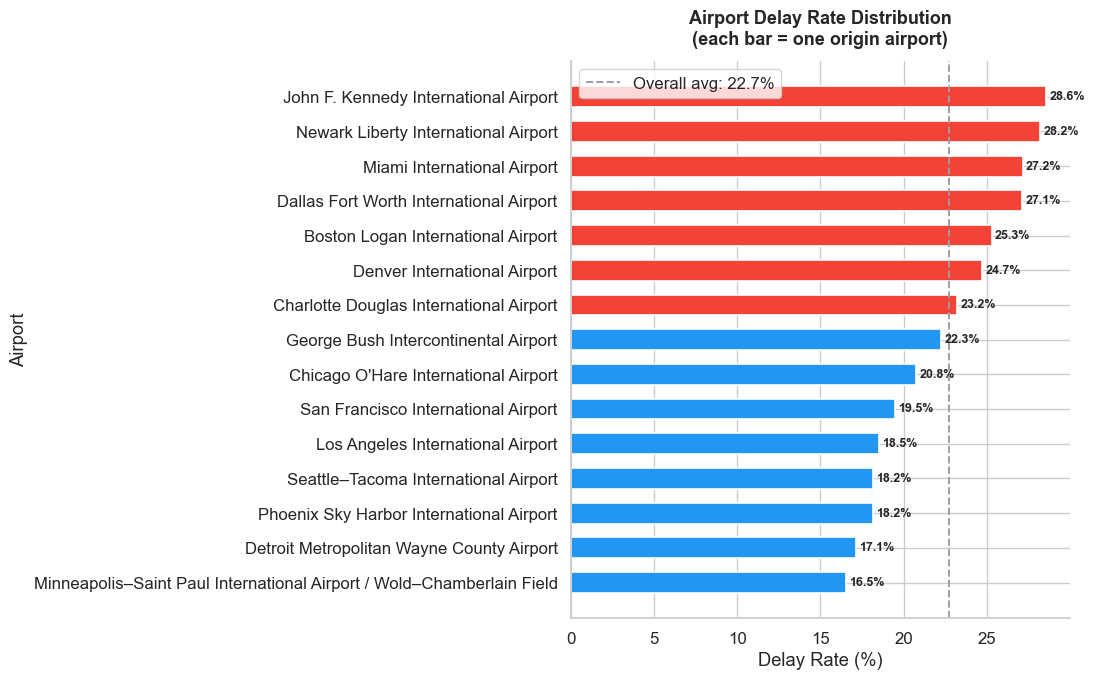

In [ ]:


fig, ax = plt.subplots(figsize=(11, 7))

airport_rates = (
    train_pre.groupby('airport_name')['departure_delayed']
    .agg(
        delay_rate='mean',
        count='size'
    )
    .reset_index()
    .sort_values('delay_rate', ascending=True)
)


overall_avg = train_pre['departure_delayed'].mean()

# Colors
bar_colors = [
    RED if r > overall_avg else BLUE
    for r in airport_rates['delay_rate']
]

# Plot
bars = ax.barh(
    airport_rates['airport_name'],
    airport_rates['delay_rate'] * 100,
    color=bar_colors,
    height=0.6,
    edgecolor='white',
    linewidth=1.2
)

# Labels
for bar, rate in zip(bars, airport_rates['delay_rate']):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{rate*100:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# Average line
ax.axvline(
    overall_avg * 100,
    color=GRAY,
    linestyle='--',
    linewidth=1.4,
    label=f'Overall avg: {overall_avg*100:.1f}%'
)

# Titles
ax.set_title(
    'Airport Delay Rate Distribution\n(each bar = one origin airport)',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Airport')

ax.legend()
sns.despine()
plt.tight_layout()

plt.savefig(FIG_DIR / 'airport_delay_rate_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight: Airport Delay Rate Distribution

The airport-level analysis shows even stronger variability in delay performance. Airports such as John F. Kennedy (JFK), Newark (EWR), and Miami (MIA) exhibit the highest delay rates (around 27–29%), all well above the overall average, indicating they are high-delay-risk hubs. These are typically busy, high-traffic airports where congestion likely contributes to delays.

On the other hand, airports like Minneapolis–Saint Paul (MSP), Detroit (DTW), and Phoenix (PHX) show significantly lower delay rates (~16–18%), suggesting more efficient operations and fewer disruptions.

---
## 12. Univariate Analysis 
**Plot type:** KDE 

**Variables:** route_delay_rate

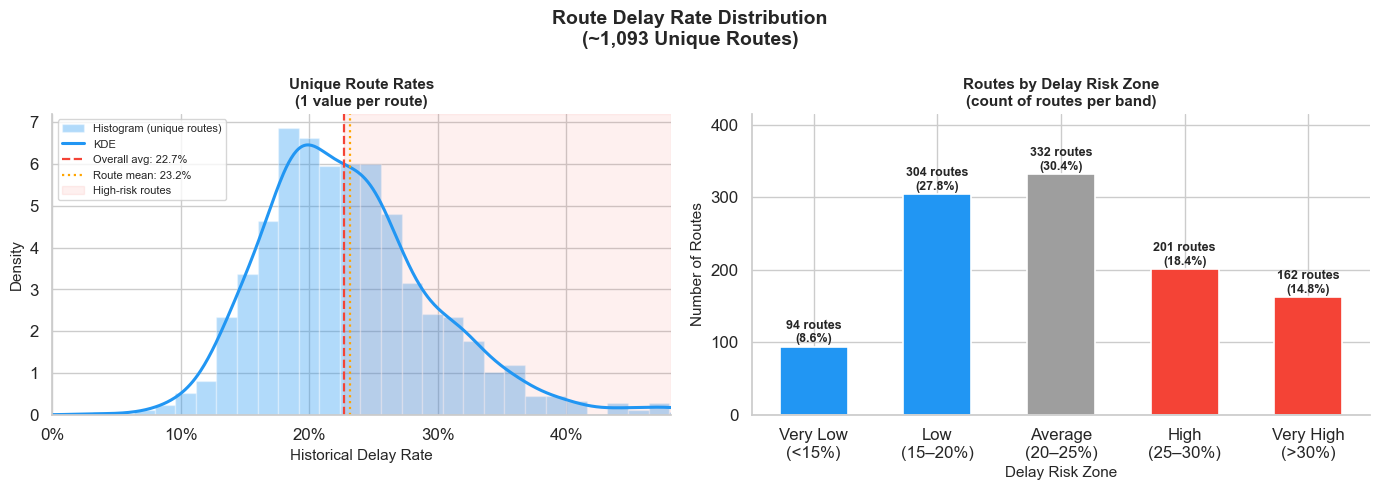


Routes ABOVE overall average (22.7%): 520 (47.6%)
Routes BELOW overall average: 573 (52.4%)


In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Route Delay Rate Distribution\n(~1,093 Unique Routes)',
             fontsize=14, fontweight='bold')

route_rates = train.drop_duplicates('route_delay_rate')['route_delay_rate'].dropna()
flight_rates = train['route_delay_rate'].dropna()  # per flight (weighted by volume)

overall_mean = train['departure_delayed'].mean()

# ── Left: 

q75, q25 = np.percentile(route_rates, [75, 25])
iqr = q75 - q25
bin_width = 2 * iqr / (len(route_rates) ** (1/3)) if iqr > 0 else 0.01
n_bins = min(int((route_rates.max() - route_rates.min()) / bin_width), 60)
n_bins = max(n_bins, 20)

axes[0].hist(route_rates, bins=n_bins, color=BLUE, alpha=0.35,
             density=True, label='Histogram (unique routes)')
route_rates.plot.kde(ax=axes[0], color=BLUE, linewidth=2.2, label='KDE')


axes[0].axvline(overall_mean, color=RED, linestyle='--',
                linewidth=1.6, label=f'Overall avg: {overall_mean*100:.1f}%')
axes[0].axvline(route_rates.mean(), color='orange', linestyle=':',
                linewidth=1.6, label=f'Route mean: {route_rates.mean()*100:.1f}%')


x_fill = route_rates[route_rates > overall_mean]
if len(x_fill) > 0:
    axes[0].axvspan(overall_mean, route_rates.quantile(0.995),
                    alpha=0.08, color=RED, label='High-risk routes')

axes[0].set_xlim(0, route_rates.quantile(0.995))
axes[0].set_title('Unique Route Rates\n(1 value per route)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Historical Delay Rate', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%')
)
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

# ── Right:

risk_bins  = [0, 0.15, 0.20, 0.25, 0.30, 1.0]
risk_labels = ['Very Low\n(<15%)', 'Low\n(15–20%)',
               'Average\n(20–25%)', 'High\n(25–30%)', 'Very High\n(>30%)']

route_risk = pd.cut(route_rates, bins=risk_bins,
                    labels=risk_labels, include_lowest=True)
risk_counts = route_risk.value_counts().reindex(risk_labels)
risk_pct    = risk_counts / risk_counts.sum() * 100

risk_colors = [BLUE, BLUE, GRAY, RED, RED]

bars = axes[1].bar(
    risk_labels,
    risk_counts.values,
    color=risk_colors,
    width=0.55,
    edgecolor='white',
    linewidth=1.2
)

for bar, count, pct in zip(bars, risk_counts.values, risk_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{count:,} routes\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[1].set_title('Routes by Delay Risk Zone\n(count of routes per band)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Routes', fontsize=11)
axes[1].set_xlabel('Delay Risk Zone', fontsize=11)
axes[1].set_ylim(0, risk_counts.max() * 1.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'extra_route_delay_rate_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()



print(f'\nRoutes ABOVE overall average ({overall_mean*100:.1f}%): '
      f'{(route_rates > overall_mean).sum():,} '
      f'({(route_rates > overall_mean).mean()*100:.1f}%)')
print(f'Routes BELOW overall average: '
      f'{(route_rates <= overall_mean).sum():,} '
      f'({(route_rates <= overall_mean).mean()*100:.1f}%)')

### Insights
route_delay_rate is a strong predictive feature because it captures historical behavior at the route level
The presence of high-risk routes (up to ~53%) indicates valuable signal for classification
Since the feature is continuous and well-distributed, it can be used directly without heavy transformation


---
## 13. Bivariate Analysis 
**Plot type:**   Clustered + Stacked Bar (Two Categorical)  
**Variables:** `Route Congestion` × `departure_delayed`

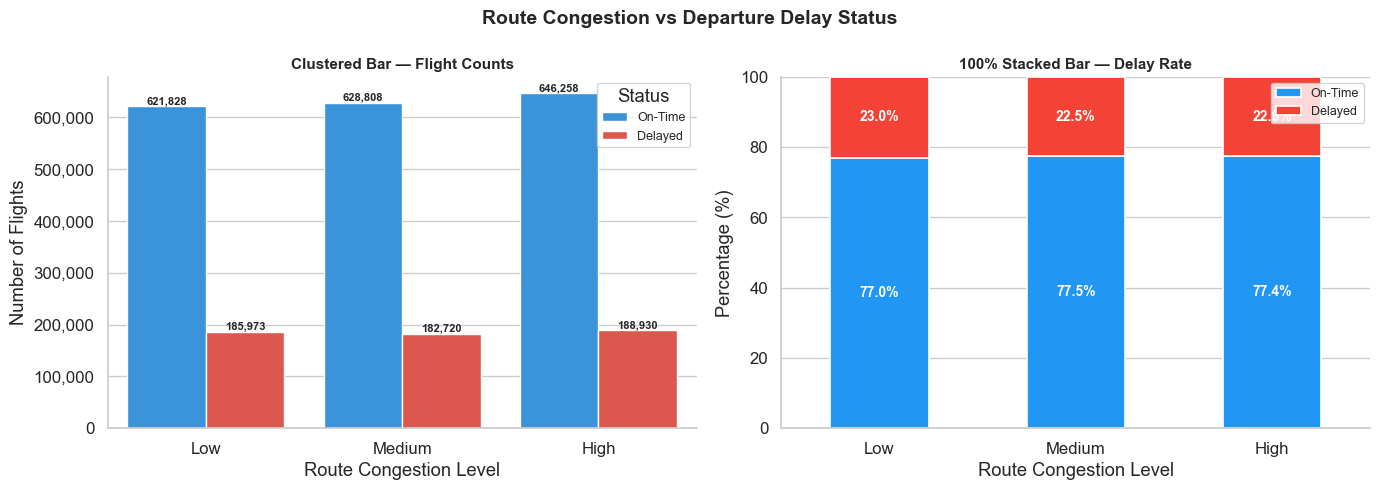


Delay rate by congestion level:
Congestion
Low       23.02
Medium    22.52
High      22.62
Name: Delayed, dtype: float64


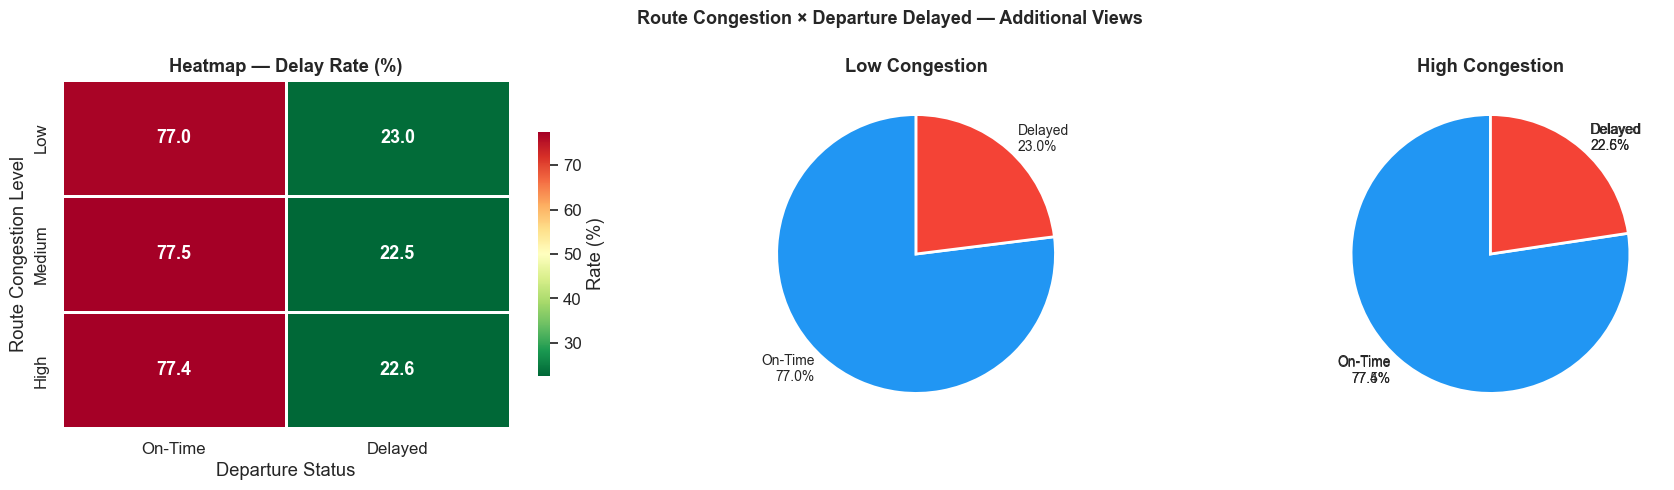

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Route Congestion vs Departure Delay Status',
             fontsize=14, fontweight='bold')

congestion_map = {0: 'Low', 1: 'Medium', 2: 'High'}
plot_df = train[['route_congestion', 'departure_delayed']].copy()
plot_df['Congestion'] = plot_df['route_congestion'].map(congestion_map)
plot_df['Status']     = plot_df['departure_delayed'].map(
    {0: 'On-Time', 1: 'Delayed'}
)

congestion_order = ['Low', 'Medium', 'High']

# ── Left: 
counts_df = (
    plot_df.groupby(['Congestion', 'Status'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=counts_df,
    x='Congestion', y='count',
    hue='Status', hue_order=['On-Time', 'Delayed'],
    palette={'On-Time': BLUE, 'Delayed': RED},
    order=congestion_order,
    ax=axes[0]
)

for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     h + 1000,
                     f'{int(h):,}',
                     ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_title('Clustered Bar — Flight Counts', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Flights')
axes[0].set_xlabel('Route Congestion Level')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[0].legend(title='Status', fontsize=9)
sns.despine(ax=axes[0])

# ── Right: 
crosstab = pd.crosstab(
    plot_df['Congestion'],
    plot_df['Status'],
    normalize='index'
) * 100
crosstab = crosstab.reindex(congestion_order)[['On-Time', 'Delayed']]

crosstab.plot(
    kind='bar', stacked=True,
    color=[BLUE, RED],
    edgecolor='white', linewidth=1.2,
    width=0.5, ax=axes[1]
)


for i, (idx, row) in enumerate(crosstab.iterrows()):
    # On-time segment
    axes[1].text(i, row['On-Time']/2,
                 f"{row['On-Time']:.1f}%",
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white')
    # Delayed segment
    axes[1].text(i, row['On-Time'] + row['Delayed']/2,
                 f"{row['Delayed']:.1f}%",
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white')

axes[1].set_title('100% Stacked Bar — Delay Rate', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Route Congestion Level')
axes[1].set_xticklabels(congestion_order, rotation=0)
axes[1].legend(['On-Time', 'Delayed'], loc='upper right', fontsize=9)
axes[1].set_ylim(0, 100)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'extra_route_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDelay rate by congestion level:')
print(crosstab['Delayed'].round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Route Congestion × Departure Delayed — Additional Views',
             fontsize=13, fontweight='bold')

# ── Left:
heat_data = pd.crosstab(
    plot_df['Congestion'],
    plot_df['Status'],
    normalize='index'
).mul(100).reindex(congestion_order)[['On-Time', 'Delayed']]

sns.heatmap(heat_data,
            annot=True, fmt='.1f', annot_kws={'size': 13, 'fontweight': 'bold'},
            cmap='RdYlGn_r', linewidths=2, linecolor='white',
            cbar_kws={'shrink': 0.7, 'label': 'Rate (%)'},
            ax=axes[0])
axes[0].set_title('Heatmap — Delay Rate (%)', fontweight='bold')
axes[0].set_xlabel('Departure Status')
axes[0].set_ylabel('Route Congestion Level')
axes[0].tick_params(axis='x', rotation=0)


for j, level in enumerate(congestion_order):
    ax = axes[j + 1] if j < 2 else axes[2]
    row = heat_data.loc[level]
    ax.pie(row.values,
           labels=[f"On-Time\n{row['On-Time']:.1f}%",
                   f"Delayed\n{row['Delayed']:.1f}%"],
           colors=[BLUE, RED],
           startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2},
           textprops={'fontsize': 10})
    ax.set_title(f'{level} Congestion', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'extra_route_congestion_b.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight: 

Delay rates remain nearly constant across congestion levels, with Low (23.0%), Medium (22.5%), and High (22.6%) showing only minimal variation. Despite expectations that higher congestion would lead to more delays, the data does not support a strong relationship.

This suggests that congestion is not a primary driver of departure delays. Airlines and airports likely mitigate congestion through scheduling buffers, optimized traffic management, and operational efficiency, especially in high-traffic environments.

---
## 14. Multivariate Analysis 
**Plot type:**   CDelay Rate Heatmap 
**Variables:** Day of Week × Time of Day

time_of_day  Early Morning  Morning  Afternoon  Evening
dow_label                                              
Mon                   15.5     23.6       24.3     30.1
Tue                   13.8     19.9       21.3     25.6
Wed                   13.9     19.0       21.7     27.5
Thu                   14.3     23.0       24.5     32.0
Fri                   16.1     23.9       26.9     33.2
Sat                   16.6     22.2       24.4     30.7
Sun                   16.5     25.7       25.9     33.2


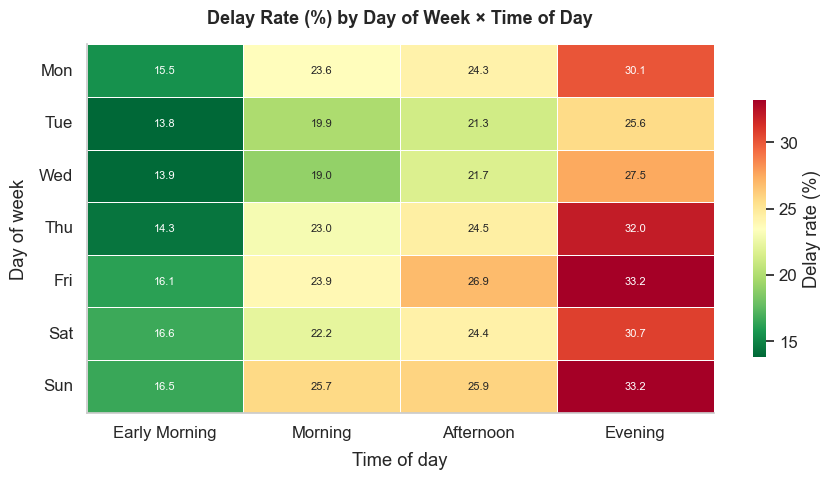


Highest-risk slots:
dow_label  time_of_day
Sun        Evening        33.2
Fri        Evening        33.2
Thu        Evening        32.0
Sat        Evening        30.7
Mon        Evening        30.1

Lowest-risk slots:
dow_label  time_of_day  
Tue        Early Morning    13.8
Wed        Early Morning    13.9
Thu        Early Morning    14.3
Mon        Early Morning    15.5
Fri        Early Morning    16.1


In [ ]:

tod_map = {
    'tod_early_morning': 'Early Morning',
    'tod_afternoon':     'Afternoon',
    'tod_evening':       'Evening',
}

def reconstruct_tod(row):
    for col, label in tod_map.items():
        if col in row.index and row[col] == 1:
            return label
    return 'Morning'

train['time_of_day'] = train.apply(reconstruct_tod, axis=1)


DOW_MAP = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
train['dow_label'] = train['day_of_week'].map(DOW_MAP)


TOD_ORDER = ['Early Morning', 'Morning', 'Afternoon', 'Evening']
DOW_ORDER = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot = (
    train
    .groupby(['dow_label', 'time_of_day'])['departure_delayed']
    .mean()
    .mul(100)
    .reset_index()
    .pivot(index='dow_label', columns='time_of_day', values='departure_delayed')
    .reindex(index=DOW_ORDER, columns=TOD_ORDER)
    .astype(float)
)

print(pivot.round(1))


fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    pivot,
    ax=ax,
    annot=True, fmt='.1f', annot_kws={'size': 8},
    cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Delay rate (%)'},
)

ax.set_title('Delay Rate (%) by Day of Week × Time of Day',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Time of day', labelpad=8)
ax.set_ylabel('Day of week', labelpad=8)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_11_delay_heatmap_dow_tod.png', dpi=150, bbox_inches='tight')
plt.show()


print('\nHighest-risk slots:')
print(pivot.stack().sort_values(ascending=False).head(5).round(1).to_string())
print('\nLowest-risk slots:')
print(pivot.stack().sort_values().head(5).round(1).to_string())